In [83]:
import requests
from bs4 import BeautifulSoup
import sqlite3
import pandas as pd
import time
import matplotlib.pyplot as plt
import re
from datetime import datetime

# グラフの日本語対応
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6)

In [105]:
class WeatherCrawler:
    """気象庁から東京の気象データを取得するクラス"""
    
    def __init__(self, year=2024, prec_no=44, block_no=47662):
        """
        Parameters:
        -----------
        year : int
            取得する年
        prec_no : int
            地域コード (44: 東京都)
        block_no : int
            観測地点コード (47662: 東京)
        """
        self.year = year
        self.prec_no = prec_no
        self.block_no = block_no
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        self.base_url = "https://www.data.jma.go.jp/stats/etrn/view/daily_s1.php"
    
    def crawl(self, start_month=1, end_month=12):
        """
        指定期間の気象データを取得
        
        Parameters:
        -----------
        start_month : int
            開始月 (1-12)
        end_month : int
            終了月 (1-12)
            
        Returns:
        --------
        list of tuple
            (year, month, day, rain, snow) のリスト
        """
        results = []
        print(f"=== {self.year}年 {start_month}月〜{end_month}月のデータ取得開始 ===")
        
        for month in range(start_month, end_month + 1):
            # 日別データのURL
            url = f"{self.base_url}?prec_no={self.prec_no}&block_no={self.block_no}&year={self.year}&month={month}&day=&view="
            
            try:
                print(f"  取得中: {month}月...", end=" ")
                res = requests.get(url, headers=self.headers, timeout=10)
                res.encoding = res.apparent_encoding
                soup = BeautifulSoup(res.content, 'html.parser')
                
                # データテーブルを取得
                table = soup.find('table', class_='data2_s')
                if not table:
                    print("テーブルが見つかりません")
                    continue
                
                # データ行を取得 (ヘッダー行をスキップ)
                rows = table.find_all('tr')[4:]
                day_count = 0
                
                for row in rows:
                    cols = row.find_all('td')
                    
                    # 日付データがある行のみ処理
                    if len(cols) > 17 and cols[0].text.strip().isdigit():
                        day = int(cols[0].text.strip())
                        
                        # 降水量 (4列目: インデックス3) - 降水量の合計
                        rain_text = cols[3].text.strip()
                        rain_text = re.sub(r'[^\d.]', '', rain_text)
                        rain = float(rain_text) if rain_text else 0.0
                        
                        # 降雪量 (18列目: インデックス17) - 降雪
                        snow_text = cols[17].text.strip()
                        snow_text = re.sub(r'[^\d.]', '', snow_text)
                        snow = float(snow_text) if snow_text else 0.0
                        
                        results.append((self.year, month, day, rain, snow))
                        day_count += 1
                
                print(f"{day_count}日分取得")
                
                # サーバー負荷軽減のため待機
                time.sleep(1)
                
            except requests.exceptions.Timeout:
                print(f"タイムアウト")
            except Exception as e:
                print(f"エラー: {e}")
        
        print(f"\n=== 取得完了: 合計 {len(results)}日分のデータ ===\n")
        return results
    
    def get_data_summary(self, data):
        """取得データの概要を表示"""
        if not data:
            print("データがありません")
            return
        
        df = pd.DataFrame(data, columns=['year', 'month', 'day', 'rain', 'snow'])
        print("=" * 50)
        print("データ概要")
        print("=" * 50)
        print(f"期間: {df['year'].iloc[0]}年{df['month'].min()}月{df['day'].min()}日 〜 {df['month'].max()}月{df['day'].max()}日")
        print(f"データ件数: {len(df)}日分")
        print(f"降水量合計: {df['rain'].sum():.1f} mm")
        print(f"降雪量合計: {df['snow'].sum():.1f} cm")
        print(f"降水日数: {(df['rain'] > 0).sum()}日")
        print(f"降雪日数: {(df['snow'] > 0).sum()}日")
        print("=" * 50)
        
        # サンプルデータ表示
        print("\n最初の10日分のデータ:")
        print(df.head(10))
        
        # 降雪がある日を表示
        snow_days = df[df['snow'] > 0]
        if len(snow_days) > 0:
            print(f"\n降雪があった日 (合計{len(snow_days)}日):")
            print(snow_days[['month', 'day', 'snow']].head(20))
        
        # 月別サマリー
        print("\n月別サマリー:")
        monthly = df.groupby('month').agg({
            'rain': 'sum',
            'snow': 'sum'
        }).reset_index()
        monthly.columns = ['Month', 'Total Rain (mm)', 'Total Snow (cm)']
        print(monthly.to_string(index=False))


# 使用例
crawler = WeatherCrawler(year=2024)
weather_data = crawler.crawl()
crawler.get_data_summary(weather_data)

=== 2024年 1月〜12月のデータ取得開始 ===
  取得中: 1月... 31日分取得
  取得中: 2月... 29日分取得
  取得中: 3月... 31日分取得
  取得中: 4月... 30日分取得
  取得中: 5月... 31日分取得
  取得中: 6月... 30日分取得
  取得中: 7月... 31日分取得
  取得中: 8月... 31日分取得
  取得中: 9月... 30日分取得
  取得中: 10月... 31日分取得
  取得中: 11月... 30日分取得
  取得中: 12月... 31日分取得

=== 取得完了: 合計 366日分のデータ ===

データ概要
期間: 2024年1月1日 〜 12月31日
データ件数: 366日分
降水量合計: 1926.0 mm
降雪量合計: 10.0 cm
降水日数: 125日
降雪日数: 2日

最初の10日分のデータ:
   year  month  day  rain  snow
0  2024      1    1   0.0   0.0
1  2024      1    2   0.0   0.0
2  2024      1    3   0.0   0.0
3  2024      1    4   0.0   0.0
4  2024      1    5   0.0   0.0
5  2024      1    6   0.0   0.0
6  2024      1    7   0.0   0.0
7  2024      1    8   0.0   0.0
8  2024      1    9   0.0   0.0
9  2024      1   10   0.0   0.0

降雪があった日 (合計2日):
    month  day  snow
35      2    5   9.0
67      3    8   1.0

月別サマリー:
 Month  Total Rain (mm)  Total Snow (cm)
     1             36.0              0.0
     2             78.5              9.0
     3            188.5    

In [106]:
class WeatherDatabase:
    """気象データを管理するデータベースクラス"""
    
    def __init__(self, db_name='weather_analysis.db'):
        self.db_name = db_name
    
    def create_table(self):
        """テーブルを作成"""
        conn = sqlite3.connect(self.db_name)
        c = conn.cursor()
        
        # 既存テーブルを削除
        c.execute('DROP TABLE IF EXISTS daily_weather')
        
        # 新しいテーブルを作成
        c.execute('''
            CREATE TABLE daily_weather (
                year INTEGER,
                month INTEGER,
                day INTEGER,
                rain REAL,
                snow REAL,
                is_heavy_rain INTEGER,
                is_heavy_snow INTEGER,
                PRIMARY KEY (year, month, day)
            )
        ''')
        
        conn.commit()
        conn.close()
        print("テーブル作成完了")
    
    def insert_data(self, data, heavy_rain_threshold=50, heavy_snow_threshold=5):
        """
        データを挿入（異常気象判定を含む）
        
        Parameters:
        -----------
        data : list of tuple
            (year, month, day, rain, snow)
        heavy_rain_threshold : float
            大雨の閾値 (mm)
        heavy_snow_threshold : float
            大雪の閾値 (cm)
        """
        conn = sqlite3.connect(self.db_name)
        c = conn.cursor()
        
        # 異常気象フラグを追加してデータを挿入
        processed_data = []
        for year, month, day, rain, snow in data:
            is_heavy_rain = 1 if rain >= heavy_rain_threshold else 0
            is_heavy_snow = 1 if snow >= heavy_snow_threshold else 0
            processed_data.append((year, month, day, rain, snow, is_heavy_rain, is_heavy_snow))
        
        c.executemany('''
            INSERT INTO daily_weather 
            VALUES (?, ?, ?, ?, ?, ?, ?)
        ''', processed_data)
        
        conn.commit()
        conn.close()
        print(f"{len(processed_data)}日分のデータを保存しました")
    
    def get_stats(self):
        """データベースの統計情報を表示"""
        conn = sqlite3.connect(self.db_name)
        
        query = '''
            SELECT 
                COUNT(*) as total_days,
                SUM(is_heavy_rain) as heavy_rain_days,
                SUM(is_heavy_snow) as heavy_snow_days,
                MAX(rain) as max_rain,
                MAX(snow) as max_snow
            FROM daily_weather
        '''
        
        df = pd.read_sql(query, conn)
        conn.close()
        
        print("\n" + "=" * 50)
        print("データベース統計")
        print("=" * 50)
        print(f"総日数: {df['total_days'].iloc[0]}日")
        print(f"大雨日数 (≥50mm): {df['heavy_rain_days'].iloc[0]}日")
        print(f"大雪日数 (≥5cm): {df['heavy_snow_days'].iloc[0]}日")
        print(f"最大降水量: {df['max_rain'].iloc[0]:.1f} mm")
        print(f"最大降雪量: {df['max_snow'].iloc[0]:.1f} cm")
        print("=" * 50 + "\n")


# データベース構築
db = WeatherDatabase()
db.create_table()
db.insert_data(weather_data)
db.get_stats()

テーブル作成完了
366日分のデータを保存しました

データベース統計
総日数: 366日
大雨日数 (≥50mm): 8日
大雪日数 (≥5cm): 1日
最大降水量: 98.0 mm
最大降雪量: 9.0 cm



In [107]:
class WeatherAnalyzer:
    """気象データの分析・可視化を行うクラス"""
    
    def __init__(self, db_name='weather_analysis.db'):
        self.db_name = db_name
    
    def get_monthly_summary(self):
        """月別の気象データサマリを取得"""
        conn = sqlite3.connect(self.db_name)
        
        query = '''
            SELECT 
                month,
                SUM(rain) as total_rain,
                SUM(snow) as total_snow,
                SUM(is_heavy_rain) as heavy_rain_days,
                SUM(is_heavy_snow) as heavy_snow_days,
                COUNT(*) as total_days
            FROM daily_weather
            GROUP BY month
            ORDER BY month
        '''
        
        df = pd.read_sql(query, conn)
        conn.close()
        return df
    
    def get_extreme_weather_dates(self, rain_threshold=50, snow_threshold=5):
        """異常気象の発生日を取得"""
        conn = sqlite3.connect(self.db_name)
        
        query = f'''
            SELECT year, month, day, rain, snow
            FROM daily_weather
            WHERE rain >= {rain_threshold} OR snow >= {snow_threshold}
            ORDER BY month, day
        '''
        
        df = pd.read_sql(query, conn)
        conn.close()
        return df
    
    def get_period_analysis(self, start_month, end_month):
        """特定期間の分析"""
        conn = sqlite3.connect(self.db_name)
        
        query = f'''
            SELECT 
                month,
                SUM(rain) as total_rain,
                SUM(snow) as total_snow,
                SUM(is_heavy_rain) as heavy_rain_days,
                SUM(is_heavy_snow) as heavy_snow_days
            FROM daily_weather
            WHERE month BETWEEN {start_month} AND {end_month}
            GROUP BY month
            ORDER BY month
        '''
        
        df = pd.read_sql(query, conn)
        conn.close()
        return df
    
    def calculate_traffic_risk_score(self):
        """月別の交通リスクスコアを計算"""
        df = self.get_monthly_summary()
        
        # リスクスコア = (大雨日数 * 3) + (大雪日数 * 5)
        # 大雪は交通への影響がより大きいため重み付けを大きくする
        df['risk_score'] = (df['heavy_rain_days'] * 3) + (df['heavy_snow_days'] * 5)
        
        return df
    
    def plot_monthly_precipitation(self):
        """月別降水量・降雪量の可視化"""
        df = self.get_monthly_summary()
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # 降水量
        bars1 = ax1.bar(df['month'], df['total_rain'], color='#1E90FF', 
                        edgecolor='black', alpha=0.8, label='Precipitation')
        ax1.set_title('Monthly Precipitation (2024)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Month', fontsize=12)
        ax1.set_ylabel('Precipitation (mm)', fontsize=12)
        ax1.set_xticks(range(1, 13))
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        
        # 降水量の数値を表示
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.0f}', ha='center', va='bottom', fontsize=9)
        
        # 降雪量
        bars2 = ax2.bar(df['month'], df['total_snow'], color='#A9A9A9', 
                        edgecolor='black', alpha=0.8, label='Snowfall')
        ax2.set_title('Monthly Snowfall (2024)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Month', fontsize=12)
        ax2.set_ylabel('Snowfall (cm)', fontsize=12)
        ax2.set_xticks(range(1, 13))
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        
        # 降雪量の数値を表示
        for bar in bars2:
            height = bar.get_height()
            if height > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
    
    def plot_extreme_weather_days(self):
        """異常気象発生日数の可視化"""
        df = self.get_monthly_summary()
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        x = df['month']
        width = 0.35
        
        bars1 = ax.bar(x - width/2, df['heavy_rain_days'], width, 
                       label='Heavy Rain Days (>=50mm)', color='#FF6B6B', edgecolor='black', alpha=0.8)
        bars2 = ax.bar(x + width/2, df['heavy_snow_days'], width, 
                       label='Heavy Snow Days (>=5cm)', color='#4ECDC4', edgecolor='black', alpha=0.8)
        
        ax.set_title('Monthly Extreme Weather Days (2024)', fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel('Month', fontsize=12)
        ax.set_ylabel('Days', fontsize=12)
        ax.set_xticks(range(1, 13))
        ax.legend(fontsize=11, loc='upper right')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # 数値を表示
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
    def plot_traffic_risk_score(self):
        """交通リスクスコアの可視化"""
        df = self.calculate_traffic_risk_score()
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        colors = ['#FF6B6B' if score > 10 else '#FFA07A' if score > 5 else '#90EE90' 
                  for score in df['risk_score']]
        
        bars = ax.bar(df['month'], df['risk_score'], color=colors, 
                      edgecolor='black', alpha=0.8, linewidth=1.5)
        
        ax.set_title('Monthly Traffic Risk Score (2024)\nFormula: (Heavy Rain Days × 3) + (Heavy Snow Days × 5)', 
                     fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel('Month', fontsize=12)
        ax.set_ylabel('Risk Score', fontsize=12)
        ax.set_xticks(range(1, 13))
        ax.axhline(y=10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='High Risk Threshold')
        ax.legend(fontsize=11)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # スコアを表示
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        return df
    
    def show_extreme_dates(self):
        """異常気象発生日の詳細を表示"""
        df = self.get_extreme_weather_dates()
        
        if df.empty:
            print("No extreme weather events found")
            return
        
        print("\n" + "=" * 70)
        print("Extreme Weather Event Details")
        print("=" * 70)
        
        for _, row in df.iterrows():
            date_str = f"{int(row['year'])}/{int(row['month'])}/{int(row['day'])}"
            
            conditions = []
            if row['rain'] >= 50:
                conditions.append(f"Heavy Rain {row['rain']:.1f}mm")
            if row['snow'] >= 5:
                conditions.append(f"Heavy Snow {row['snow']:.1f}cm")
            
            print(f"{date_str}: {' / '.join(conditions)}")
        
        print("=" * 70 + "\n")


# 分析インスタンスの作成
analyzer = WeatherAnalyzer()

仮説検証: 東京における異常気象の月別集中度と交通リスク分析

【1】月別降水量・降雪量の推移


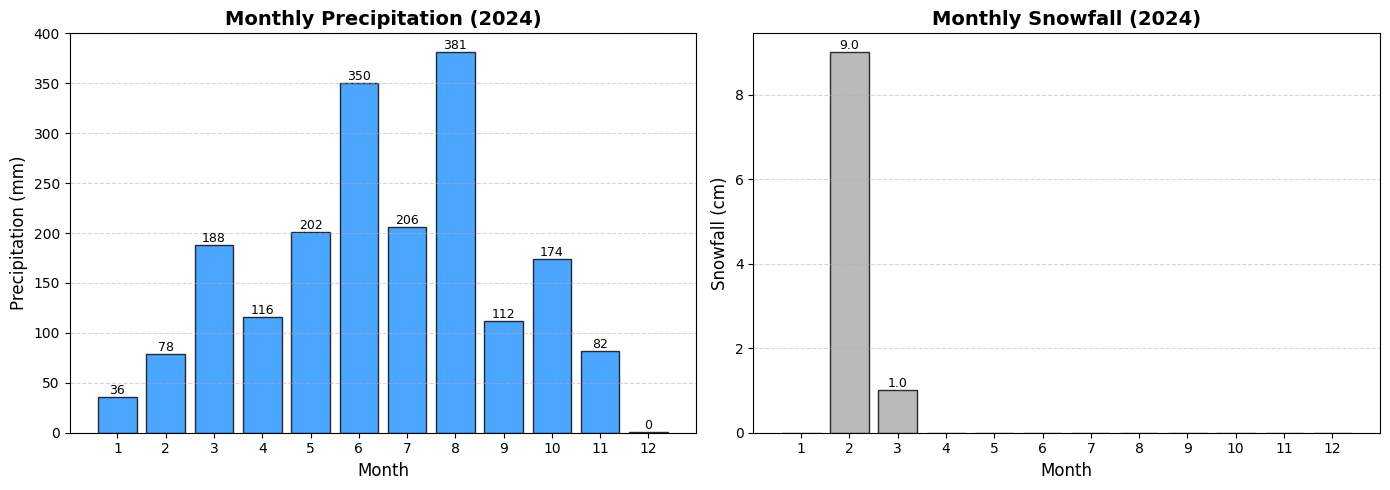


【2】異常気象(大雨・大雪)の発生日数


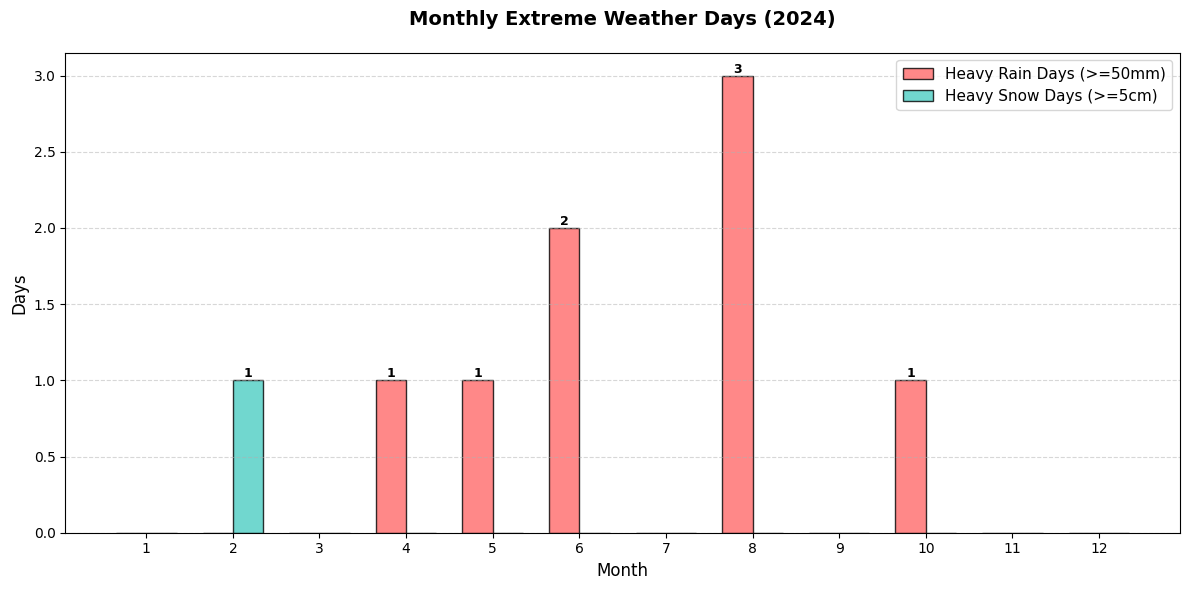


【3】交通リスクスコアの評価


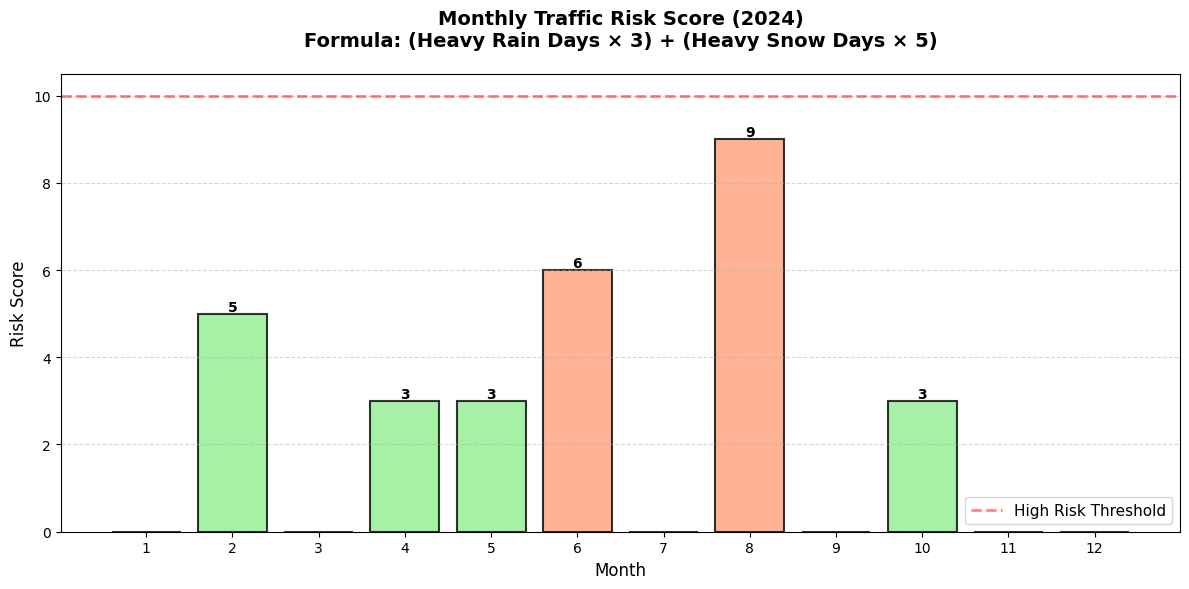


【4】異常気象発生日の詳細情報

Extreme Weather Event Details
2024/2/5: Heavy Snow 9.0cm
2024/4/9: Heavy Rain 55.5mm
2024/5/13: Heavy Rain 58.5mm
2024/6/18: Heavy Rain 98.0mm
2024/6/28: Heavy Rain 82.5mm
2024/8/7: Heavy Rain 76.5mm
2024/8/16: Heavy Rain 90.0mm
2024/8/30: Heavy Rain 84.0mm
2024/10/9: Heavy Rain 53.5mm


【5】月別統計サマリー
 month  total_rain  total_snow  heavy_rain_days  heavy_snow_days  total_days
     1        36.0         0.0                0                0          31
     2        78.5         9.0                0                1          29
     3       188.5         1.0                0                0          31
     4       115.5         0.0                1                0          30
     5       201.5         0.0                1                0          31
     6       350.0         0.0                2                0          30
     7       206.5         0.0                0                0          31
     8       381.0         0.0                3                0 

In [108]:
print("=" * 80)
print("仮説検証: 東京における異常気象の月別集中度と交通リスク分析")
print("=" * 80)
print()

# 1. 月別降水量・降雪量
print("【1】月別降水量・降雪量の推移")
analyzer.plot_monthly_precipitation()

# 2. 異常気象発生日数
print("\n【2】異常気象(大雨・大雪)の発生日数")
analyzer.plot_extreme_weather_days()

# 3. 交通リスクスコア
print("\n【3】交通リスクスコアの評価")
risk_df = analyzer.plot_traffic_risk_score()

# 4. 異常気象発生日の詳細
print("\n【4】異常気象発生日の詳細情報")
analyzer.show_extreme_dates()

# 5. 統計サマリー
print("\n【5】月別統計サマリー")
summary = analyzer.get_monthly_summary()
print(summary.to_string(index=False))

print("\n" + "=" * 80)
print("検証結果のサマリー")
print("=" * 80)

# 最もリスクが高い月を特定
max_risk_month = risk_df.loc[risk_df['risk_score'].idxmax(), 'month']
max_risk_score = risk_df.loc[risk_df['risk_score'].idxmax(), 'risk_score']

print(f"✓ 最高リスク月: {int(max_risk_month)}月 (スコア: {int(max_risk_score)})")
print(f"✓ 大雨発生総日数: {int(risk_df['heavy_rain_days'].sum())}日")
print(f"✓ 大雪発生総日数: {int(risk_df['heavy_snow_days'].sum())}日")

high_risk_months = risk_df[risk_df['risk_score'] > 10]['month'].tolist()
if high_risk_months:
    months_str = "、".join([f"{int(m)}月" for m in high_risk_months])
    print(f"✓ 高リスク月(スコア>10): {months_str}")
else:
    print("✓ 高リスク月(スコア>10): なし")

print("=" * 80)